# CASE 1 - Signe

In [78]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data = pd.read_csv('data/case1Data_preprocessed.csv')
data.head()

,y,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,...,C_04_73.0,C_04_74.0,C_04_75.0,C_04_nan,C_05_71.0,C_05_72.0,C_05_73.0,C_05_74.0,C_05_75.0,C_05_nan
0,375.823073,6.359019,-13.367120,-2.483750,-6.641891,11.733539,-4.057966,-17.085361,22.194764,16.827888,...,True,False,False,False,False,False,True,False,False,False
1,266.811730,3.873664,-8.470389,-3.055012,-6.029949,11.420983,1.822330,-13.694100,22.738654,20.307503,...,True,False,False,False,False,False,True,False,False,False
2,267.271759,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,22.439790,15.963889,...,False,True,False,False,False,False,False,True,False,False
3,219.951294,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,...,False,False,False,False,False,True,False,False,False,False
4,289.697954,3.116458,-8.518713,-6.796050,-6.029949,7.646285,-3.118309,-13.102567,22.801217,16.680208,...,False,True,False,False,False,False,False,False,True,False


In [ ]:
X = data_filled.drop('y', axis=1)
y = data_filled['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [88]:
from sklearn.linear_model import ElasticNetCV

alpha = 1   # 0=ridge, 1=lasso
lambdas = np.logspace(-4, 4, 100)
model_cv = ElasticNetCV(l1_ratio=alpha, alphas=lambdas, cv=5, max_iter=100000)
model_cv.fit(X_train, y_train)

best_lambda_cv = model_cv.alpha_
print("Best lambda via CV:", best_lambda_cv)
print("Nonzero coefficients:", np.sum(model_cv.coef_ != 0))

Best lambda via CV: 0.9111627561154896
Nonzero coefficients: 43


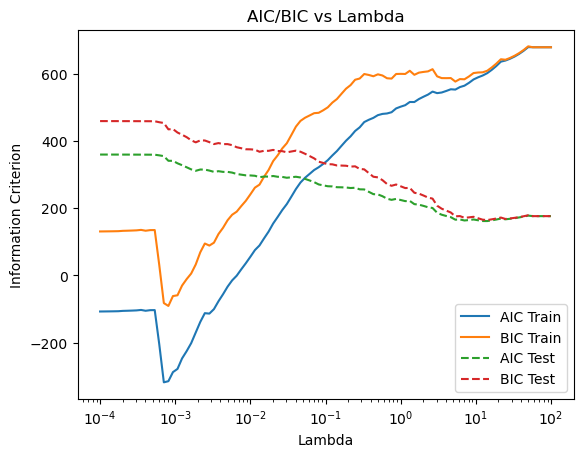

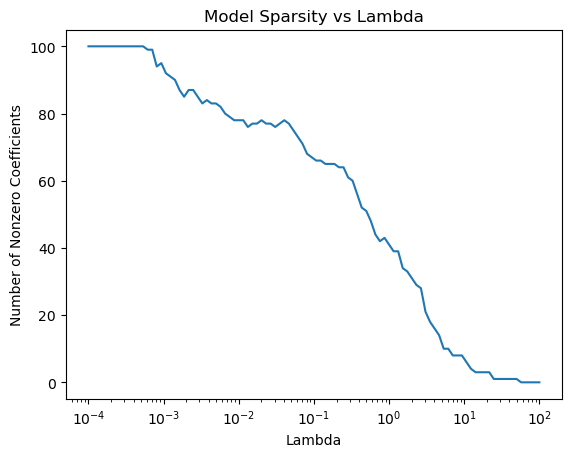

In [89]:
n_train = X_train.shape[0]
n_test = X_test.shape[0]

# Standardize predictors
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Lambda grid
lambdas = np.logspace(-4, 2, 100)

aic_train = []
bic_train = []
aic_test = []
bic_test = []
df_values = []

alpha = 1  # Lasso

for lam in lambdas:
    model = ElasticNet(alpha=lam, l1_ratio=alpha, fit_intercept=True, max_iter=100000)
    model.fit(X_train, y_train)

    # -------- TRAIN --------
    res_train = y_train - model.predict(X_train)
    rss_train = np.sum(res_train**2)
    sigma2_train = rss_train / n_train
    logL_train = -n_train/2 * np.log(sigma2_train)

    # -------- TEST --------
    res_test = y_test - model.predict(X_test)
    rss_test = np.sum(res_test**2)
    sigma2_test = rss_test / n_test
    logL_test = -n_test/2 * np.log(sigma2_test)

    df = np.sum(model.coef_ != 0)

    AIC_train = -2 * logL_train + 2 * df
    BIC_train = -2 * logL_train + np.log(n_train) * df

    AIC_test = -2 * logL_test + 2 * df
    BIC_test = -2 * logL_test + np.log(n_test) * df

    aic_train.append(AIC_train)
    bic_train.append(BIC_train)
    aic_test.append(AIC_test)
    bic_test.append(BIC_test)
    df_values.append(df)

# -------- Plot AIC/BIC --------
plt.figure()
plt.plot(lambdas, aic_train, label="AIC Train")
plt.plot(lambdas, bic_train, label="BIC Train")
plt.plot(lambdas, aic_test, '--', label="AIC Test")
plt.plot(lambdas, bic_test, '--', label="BIC Test")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Information Criterion")
plt.title("AIC/BIC vs Lambda")
plt.legend()
plt.show()

# -------- Sparsity plot --------
plt.figure()
plt.plot(lambdas, df_values)
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Number of Nonzero Coefficients")
plt.title("Model Sparsity vs Lambda")
plt.show()

In [90]:
# Minimum lambda values for AIC and BIC
min_aic = min(aic_test)
min_bic = min(bic_test)
best_aic_lambda = lambdas[aic_test.index(min_aic)]
best_bic_lambda = lambdas[bic_test.index(min_bic)]
print("Minimum AIC:", min_aic)
print("Best lambda (AIC):", best_aic_lambda)
print("Minimum BIC:", min_bic)
print("Best lambda (BIC):", best_bic_lambda)

# Number of nonzero coefficients for best AIC and BIC models
best_aic_model = ElasticNet(alpha=best_aic_lambda, l1_ratio=alpha, fit_intercept=True, max_iter=10000)
best_aic_model.fit(X_train, y_train)
best_bic_model = ElasticNet(alpha=best_bic_lambda, l1_ratio=alpha, fit_intercept=True, max_iter=10000)
best_bic_model.fit(X_train, y_train)
print("Nonzero coefficients (AIC):", np.sum(best_aic_model.coef_ != 0))
print("Nonzero coefficients (BIC):", np.sum(best_bic_model.coef_ != 0))

Minimum AIC: 161.48902148307607
Best lambda (AIC): 14.174741629268048
Minimum BIC: 164.47621830373805
Best lambda (BIC): 14.174741629268048
Nonzero coefficients (AIC): 3
Nonzero coefficients (BIC): 3


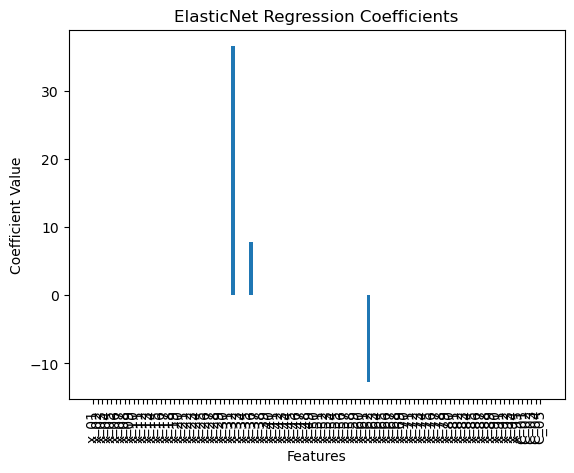

In [91]:
# Plot the coefficients of the features
X = data_filled.drop('y', axis=1)
feature_names = X.columns
coefficients = best_aic_model.coef_
plt.bar(feature_names, coefficients)
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('ElasticNet Regression Coefficients')
plt.xticks(rotation=90)
plt.show()

Mean Squared Error: 999.1502225650568


/Users/signeolsen/opt/anaconda3/envs/cda/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.900e+03, tolerance: 3.869e+01
  model = cd_fast.enet_coordinate_descent(


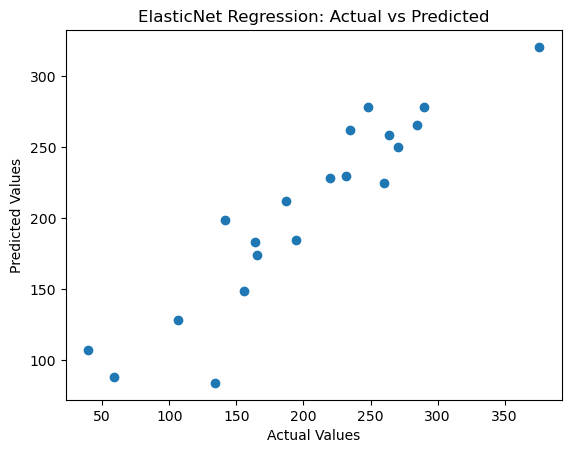

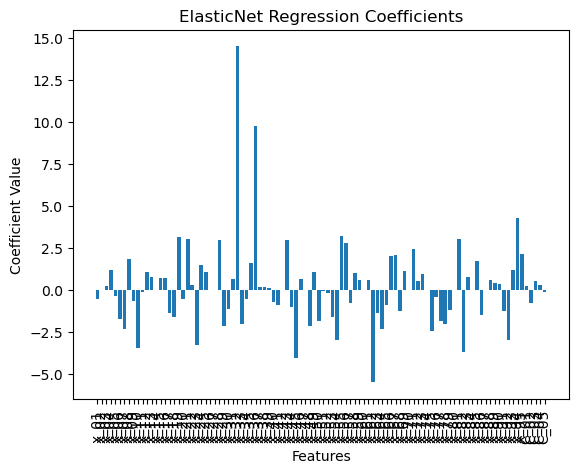

In [16]:
# ElasticNet Regression
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Define features and target variable
X = data_filled.drop('y', axis=1)
y = data_filled['y']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize and fit the ElasticNet model
model = ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=42)
model.fit(X_train, y_train)
# Predict and evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


# Plot the predicted vs actual values
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('ElasticNet Regression: Actual vs Predicted')
plt.show()

# Plot the coefficients of the features
feature_names = X.columns
coefficients = model.coef_
plt.bar(feature_names, coefficients)
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('ElasticNet Regression Coefficients')
plt.xticks(rotation=90)
plt.show()